# 06. Model Evaluation, Benchmarking & Champion Selection

This notebook queries all trained model runs from Databricks MLflow tracking, computes operational serving benchmarks (latency, memory size, batch throughput), performs business ROI financial calculations, and selects the production **Champion** model based on a multi-criteria decision matrix.

## Phase 1: Retrieve MLflow Metrics & Run Metadata

In [19]:
# Phase 1: Connect to MLflow, Extract Runs, and Clean Leaderboard Metrics
import mlflow
from mlflow.tracking import MlflowClient
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# 1. Connect to Databricks MLflow Tracking Server
mlflow.set_tracking_uri("databricks")
experiment_name = "/Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk"
experiment = mlflow.get_experiment_by_name(experiment_name)

# 2. Query all finished experiment runs
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["metrics.val_pr_auc DESC"]
)

# 3. Select and standardize metric and metadata columns
selected_columns = {
    'tags.mlflow.runName': 'model_name',
    'params.model_type': 'model_type',
    'metrics.val_pr_auc': 'val_pr_auc',
    'metrics.val_roc_auc': 'val_roc_auc',
    'metrics.val_f1_late': 'val_f1',
    'metrics.val_recall_late': 'val_recall',
    'metrics.val_precision_late': 'val_precision',
    'metrics.val_top10pct_capture': 'val_top10_capture',
    'metrics.train_f1_late': 'train_f1',
    'metrics.test_pr_auc': 'test_pr_auc',
    'metrics.test_f1_late': 'test_f1',
    'start_time': 'created_at',
    'run_id': 'run_id'
}

eval_df = runs_df[[col for col in selected_columns.keys() if col in runs_df.columns]].copy()
eval_df.rename(columns=selected_columns, inplace=True)

# 4. Compute Overfitting / Generalization Gap (Train F1 - Val F1)
eval_df['overfitting_gap'] = (eval_df['train_f1'] - eval_df['val_f1']).round(4)
eval_df = eval_df.sort_values(by='val_pr_auc', ascending=False).reset_index(drop=True)

# Display clean initial metrics table
eval_df

,model_name,model_type,val_pr_auc,val_roc_auc,val_f1,val_recall,val_precision,val_top10_capture,train_f1,test_pr_auc,test_f1,created_at,run_id,overfitting_gap
0,model_ensemble_logreg_w_xgboost,ensemble_logreg_w_xgboost,0.197227,0.750984,0.209776,0.792250,0.120894,0.322928,0.330738,NaN,NaN,2026-08-26 22:32:04.488000+00:00,d18a787b8dd544c1ba9f901194caaf60,0.1210
1,xgboost_with_tuning,xgboost,0.181056,0.697551,0.162772,0.108719,0.323718,0.297094,0.515418,NaN,NaN,2026-08-25 19:39:25.295000+00:00,97805e82aefa4759827d9afd73768c06,0.3526
2,catboost_with_tuning,catboost,0.180914,0.699344,0.215661,0.530678,0.135328,0.276642,0.374055,NaN,NaN,2026-08-25 21:20:57.307000+00:00,f8ed0651b06b415d9c154a7f2017e03d,0.1584
3,lightgbm_with_tuning,lightgbm,0.174872,0.694813,0.218475,0.495156,0.140158,0.290635,0.416754,NaN,NaN,2026-08-25 20:30:46.564000+00:00,638ae3cc6d244e6f86e582bacc250202,0.1983
4,logistic_regression_regularized,logistic_regression_regularized,0.171194,0.752470,0.217372,0.777180,0.126356,0.302476,0.282691,NaN,NaN,2026-08-26 19:55:27.493000+00:00,9df6b38c1fdd4cfea51616d96288dfb8,0.0653
5,logistic_regression_baseline,logistic_regression,0.170727,0.752054,0.216965,0.775027,0.126139,0.302476,0.282525,NaN,NaN,2026-08-24 20:55:10.685000+00:00,8e83884790114ff2b1b8eaae35b8446d,0.0656
6,random_forest_with_tuning,random_forest,0.133198,0.654283,0.192341,0.354144,0.132022,0.244349,0.423945,NaN,NaN,2026-08-25 20:40:11.798000+00:00,336531251f3144dba1711f6b26b1d8b5,0.2316
7,champion_ensemble_test_evaluation,champion_ensemble_lr_xgb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.128928,0.1115,2026-08-26 22:35:40.117000+00:00,b560f853c1e24978ab3f8b860513e84c,NaN


## Phase 2: Complexity & Serving Benchmarks (Inference Latency, Memory & Throughput)

In [20]:
# Phase 2.1: Load Validation Sample Payload for Serving Benchmarks
import time
import sys
import pickle
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# 1. Locate validation dataset (checks Databricks Unity Catalog Volume first, then local fallback)
volume_path = Path("/Volumes/revenue_operations/gold/ml_datasets/delivery_risk_val")
local_path_rel = Path("../data/external/val") if Path("../data/external/val").exists() else Path("data/external/val")
folder = volume_path if volume_path.exists() else local_path_rel

parquets = list(folder.glob("*.parquet"))
if not parquets:
    raise FileNotFoundError(f"No parquet files found in {folder}")

def sparse_to_dense(indices_col, values_col, size_col, prefix):
    size = int(size_col.iloc[0])
    n = len(indices_col)
    dense_matrix = np.zeros((n, size), dtype=np.float32)
    for row_idx, (idx_arr, val_arr) in enumerate(zip(indices_col, values_col)):
        if idx_arr is not None and len(idx_arr) > 0:
            for i, idx in enumerate(idx_arr):
                if idx is not None:
                    val = 1.0
                    if val_arr is not None and i < len(val_arr) and val_arr[i] is not None:
                        val = float(val_arr[i])
                    dense_matrix[row_idx, int(idx)] = val
    return pd.DataFrame(dense_matrix, columns=[f"{prefix}_{i}" for i in range(size)])

raw_val = pd.concat([pd.read_parquet(p, engine="fastparquet") for p in parquets], ignore_index=True)

extra_dfs = []
vector_cols_to_drop = []
for prefix in ["customer_state_encoded", "primary_product_category_encoded"]:
    if f"{prefix}.indices" in raw_val.columns:
        clean_name = "customer_state" if "customer_state" in prefix else "product_category"
        expanded = sparse_to_dense(raw_val[f"{prefix}.indices"], raw_val[f"{prefix}.values"], raw_val[f"{prefix}.size"], clean_name)
        extra_dfs.append(expanded)
        vector_cols_to_drop.extend([f"{prefix}.type", f"{prefix}.size", f"{prefix}.indices", f"{prefix}.values"])

exclude = ["order_id", "late_delivery_flag_indexed"] + vector_cols_to_drop
feature_cols = [c for c in raw_val.columns if c not in exclude]
X_val_sample = raw_val[feature_cols].copy()
if extra_dfs:
    X_val_sample = pd.concat([X_val_sample] + extra_dfs, axis=1)

# 2. Prepare single payload (API test) and batch payload (1k records)
single_record = X_val_sample.iloc[[0]]
batch_1k = X_val_sample.head(1000)

# Scaler for models requiring normalized inputs
scaler = StandardScaler()
scaler.fit(X_val_sample)
single_record_scaled = scaler.transform(single_record)
batch_1k_scaled = scaler.transform(batch_1k)

print(f"✓ Benchmark payload ready: {X_val_sample.shape[1]} features (Source: {folder})")

✓ Benchmark payload ready: 138 features (Source: ..\data\external\val)


In [21]:
# Phase 2.2: Run Latency, Model Size & Throughput Benchmarks
benchmark_records = []

for idx, row in eval_df.iterrows():
    run_id = row['run_id']
    model_name = row['model_name']
    
    raw_run = runs_df[runs_df['run_id'] == run_id].iloc[0]
    train_duration_sec = None
    if pd.notnull(raw_run.get('start_time')) and pd.notnull(raw_run.get('end_time')):
        train_duration_sec = round((raw_run['end_time'] - raw_run['start_time']).total_seconds(), 1)
        
    print(f"Benchmarking: {model_name}...")
    model_size_mb, p50_latency, p95_latency, throughput = None, None, None, None
    
    try:
        if "ensemble" in model_name and "test" not in model_name:
            # 1. Load both ensemble sub-models
            lr_sub = mlflow.sklearn.load_model(f"runs:/{run_id}/logistic_regression_model")
            xgb_sub = mlflow.xgboost.load_model(f"runs:/{run_id}/xgboost_model")
            
            model_size_mb = round((sys.getsizeof(pickle.dumps(lr_sub)) + sys.getsizeof(pickle.dumps(xgb_sub))) / (1024 * 1024), 2)
            
            def predict_ensemble(X_raw, X_sc):
                p_lr = lr_sub.predict_proba(X_sc)[:, 1]
                p_xgb = xgb_sub.predict_proba(X_raw)[:, 1]
                return 0.5 * p_lr + 0.5 * p_xgb
            
            # Warmup
            for _ in range(10):
                _ = predict_ensemble(single_record, single_record_scaled)
                
            # Single-record latency (50 runs)
            latencies = []
            for _ in range(50):
                t0 = time.perf_counter_ns()
                _ = predict_ensemble(single_record, single_record_scaled)
                t1 = time.perf_counter_ns()
                latencies.append((t1 - t0) / 1e6)
                
            p50_latency = round(np.percentile(latencies, 50), 2)
            p95_latency = round(np.percentile(latencies, 95), 2)
            
            # Batch throughput
            t0 = time.perf_counter()
            _ = predict_ensemble(batch_1k, batch_1k_scaled)
            t1 = time.perf_counter()
            throughput = round(len(batch_1k) / (t1 - t0), 0)
            
        elif "test_evaluation" in model_name:
            # Inherits the ensemble's serving profile
            model_size_mb, p50_latency, p95_latency, throughput = None, None, None, None
            
        else:
            # Standard single model
            model = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
            model_size_mb = round(sys.getsizeof(pickle.dumps(model._model_impl)) / (1024 * 1024), 2)
            
            for _ in range(10):
                _ = model.predict(single_record)
                
            latencies = []
            for _ in range(50):
                t0 = time.perf_counter_ns()
                _ = model.predict(single_record)
                t1 = time.perf_counter_ns()
                latencies.append((t1 - t0) / 1e6)
                
            p50_latency = round(np.percentile(latencies, 50), 2)
            p95_latency = round(np.percentile(latencies, 95), 2)
            
            t0 = time.perf_counter()
            _ = model.predict(batch_1k)
            t1 = time.perf_counter()
            throughput = round(len(batch_1k) / (t1 - t0), 0)
            
    except Exception as e:
        pass
        
    benchmark_records.append({
        'run_id': run_id,
        'train_duration_sec': train_duration_sec,
        'model_size_mb': model_size_mb,
        'latency_p50_ms': p50_latency,
        'latency_p95_ms': p95_latency,
        'batch_throughput_rps': throughput
    })

# Merge benchmark results into leaderboard
benchmark_df = pd.DataFrame(benchmark_records)
leaderboard_df = eval_df.merge(benchmark_df, on='run_id')

leaderboard_df[['model_name', 'val_pr_auc', 'val_top10_capture', 'overfitting_gap', 'model_size_mb', 'latency_p95_ms', 'batch_throughput_rps', 'train_duration_sec']]

Benchmarking: model_ensemble_logreg_w_xgboost...
Benchmarking: xgboost_with_tuning...
Benchmarking: catboost_with_tuning...
Benchmarking: lightgbm_with_tuning...
Benchmarking: logistic_regression_regularized...
Benchmarking: logistic_regression_baseline...


2026/08/26 20:29:55 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.15.1, required: mlflow==3.8.1)
 - cloudpickle (current: 3.1.2, required: cloudpickle==3.0.0)
 - lz4 (current: uninstalled, required: lz4==4.3.2)
 - pandas (current: 2.3.3, required: pandas==2.2.3)
 - psutil (current: 7.2.2, required: psutil==5.9.0)
 - scikit-learn (current: 1.9.0, required: scikit-learn==1.6.1)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/08/26 20:29:55 WARNING mlflow.pyfunc: The version of Python that the model was saved in, `Python 3.12.3`, differs from the version of Python that is currently running, `Python 3.13.14`, and may be incompatible


Benchmarking: random_forest_with_tuning...
Benchmarking: champion_ensemble_test_evaluation...


,model_name,val_pr_auc,val_top10_capture,overfitting_gap,model_size_mb,latency_p95_ms,batch_throughput_rps,train_duration_sec
0,model_ensemble_logreg_w_xgboost,0.197227,0.322928,0.1210,3.53,5.52,153690.0,48.8
1,xgboost_with_tuning,0.181056,0.297094,0.3526,3.53,11.01,76127.0,156.4
2,catboost_with_tuning,0.180914,0.276642,0.1584,0.30,3.22,226521.0,371.3
3,lightgbm_with_tuning,0.174872,0.290635,0.1983,NaN,NaN,NaN,193.9
4,logistic_regression_regularized,0.171194,0.302476,0.0653,0.00,0.12,2346316.0,1617.5
5,logistic_regression_baseline,0.170727,0.302476,0.0656,0.00,2.29,262460.0,18.5
6,random_forest_with_tuning,0.133198,0.244349,0.2316,29.28,13.14,26360.0,341.7
7,champion_ensemble_test_evaluation,NaN,NaN,NaN,NaN,NaN,NaN,8.9


## Phase 3: Business ROI Calculation & Multi-Criteria Champion Selection

In [22]:
# Phase 3.1: Financial Payoff Simulation & Composite Production Scoring
# 1. Business Cost Parameters (Per 10,000 Orders Baseline)
BASELINE_ORDERS = 10000
LATE_RATE = 0.08  # ~8% baseline late delivery rate
TOTAL_LATE_ORDERS = BASELINE_ORDERS * LATE_RATE # 800 late orders

COST_MISSED_LATE = 45.00   # Financial penalty per late delivery (ticket handling, refunds, churn)
COST_INTERVENTION = 4.00   # Cost per proactive alert & logistics expedited reroute

# 2. Financial Payoff Simulation (Top 10% Operations Capacity = 1,000 alerts)
leaderboard_df['orders_inspected'] = BASELINE_ORDERS * 0.10 
leaderboard_df['late_orders_caught'] = (TOTAL_LATE_ORDERS * leaderboard_df['val_top10_capture']).round(0)
leaderboard_df['gross_loss_prevented'] = leaderboard_df['late_orders_caught'] * COST_MISSED_LATE
leaderboard_df['intervention_cost'] = leaderboard_df['orders_inspected'] * COST_INTERVENTION
leaderboard_df['net_business_value'] = (leaderboard_df['gross_loss_prevented'] - leaderboard_df['intervention_cost']).round(2)

# 3. Composite Production Score (0 to 100 Scale)
# Weights: PR-AUC (40%), Top-10% Capture (30%), Generalization Stability (15%), Latency SLA (15%)
max_pr = leaderboard_df['val_pr_auc'].max() if leaderboard_df['val_pr_auc'].max() > 0 else 1
max_cap = leaderboard_df['val_top10_capture'].max() if leaderboard_df['val_top10_capture'].max() > 0 else 1

leaderboard_df['composite_score'] = (
    0.40 * (leaderboard_df['val_pr_auc'] / max_pr) +
    0.30 * (leaderboard_df['val_top10_capture'] / max_cap) +
    0.15 * (1 - leaderboard_df['overfitting_gap'].clip(0, 1)) +
    0.15 * (1 - (leaderboard_df['latency_p95_ms'].fillna(15).clip(0, 50) / 50))
) * 100
leaderboard_df['composite_score'] = leaderboard_df['composite_score'].round(2)

# 4. Production Deployment Status Assignment
def assign_status(row, top_score):
    if pd.isnull(row['val_pr_auc']):
        return "Test Evaluation Split"
    elif row['composite_score'] == top_score:
        return "CHAMPION (Deploy)"
    elif row['composite_score'] >= top_score * 0.88:
        return "CHALLENGER (Standby)"
    else:
        return "REJECTED"

valid_scores = leaderboard_df.dropna(subset=['val_pr_auc'])['composite_score']
top_score = valid_scores.max() if len(valid_scores) > 0 else 0
leaderboard_df['deployment_status'] = leaderboard_df.apply(lambda r: assign_status(r, top_score), axis=1)

# Display Decision Matrix
display_cols = [
    'model_name', 
    'val_pr_auc', 
    'val_top10_capture', 
    'overfitting_gap',
    'net_business_value', 
    'latency_p95_ms', 
    'composite_score', 
    'deployment_status'
]
leaderboard_df[display_cols].sort_values(by='composite_score', ascending=False).reset_index(drop=True)

,model_name,val_pr_auc,val_top10_capture,overfitting_gap,net_business_value,latency_p95_ms,composite_score,deployment_status
0,model_ensemble_logreg_w_xgboost,0.197227,0.322928,0.1210,7610.0,5.52,96.53,CHAMPION (Deploy)
1,logistic_regression_regularized,0.171194,0.302476,0.0653,6890.0,0.12,91.80,CHALLENGER (Standby)
2,logistic_regression_baseline,0.170727,0.302476,0.0656,6890.0,2.29,91.05,CHALLENGER (Standby)
3,catboost_with_tuning,0.180914,0.276642,0.1584,5945.0,3.22,89.05,CHALLENGER (Standby)
4,xgboost_with_tuning,0.181056,0.297094,0.3526,6710.0,11.01,85.73,CHALLENGER (Standby)
5,lightgbm_with_tuning,0.174872,0.290635,0.1983,6485.0,NaN,84.99,CHALLENGER (Standby)
6,random_forest_with_tuning,0.133198,0.244349,0.2316,4775.0,13.14,72.30,REJECTED
7,champion_ensemble_test_evaluation,NaN,NaN,NaN,NaN,NaN,NaN,Test Evaluation Split


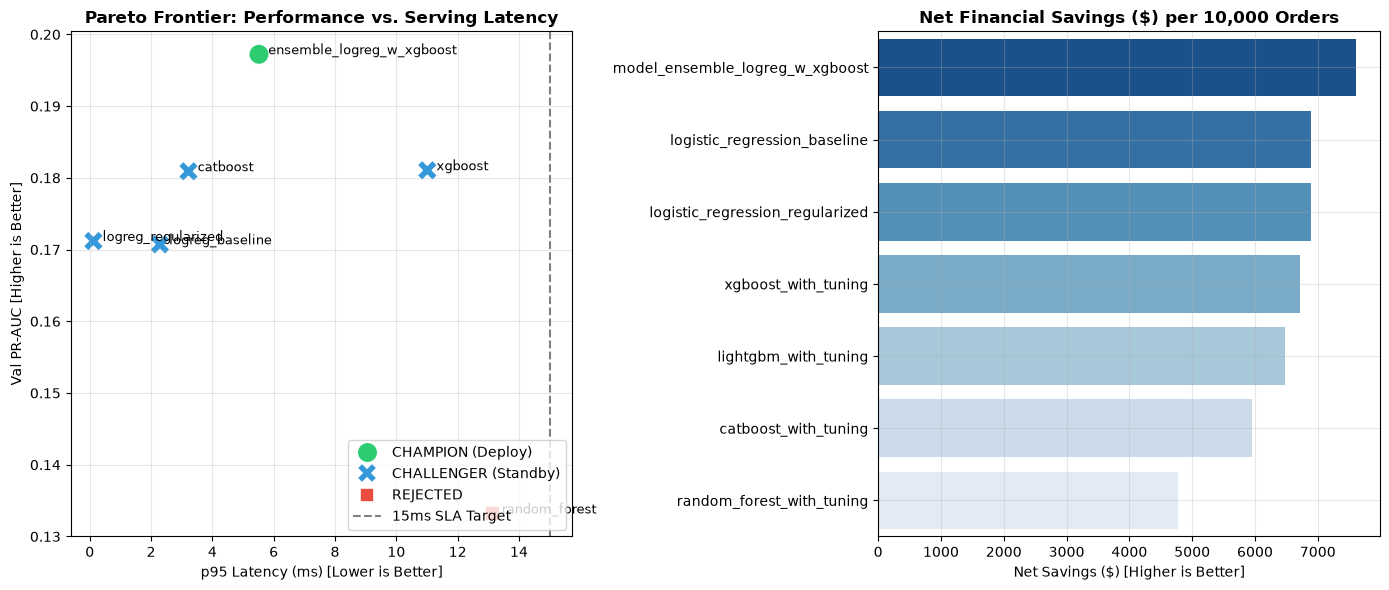

In [23]:
# Phase 3.2: Pareto Frontier & Financial Savings Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# 1. Pareto Frontier: PR-AUC vs. p95 Latency
plt.subplot(1, 2, 1)
plot_data = leaderboard_df.dropna(subset=["val_pr_auc", "latency_p95_ms"])
palette_map = {"CHAMPION (Deploy)": "#2ecc71", "CHALLENGER (Standby)": "#3498db", "REJECTED": "#e74c3c"}
sns.scatterplot(
    data=plot_data,
    x="latency_p95_ms",
    y="val_pr_auc",
    hue="deployment_status",
    style="deployment_status",
    s=220,
    palette=palette_map
)

for _, r in plot_data.iterrows():
    short_name = r["model_name"].replace("_with_tuning", "").replace("model_", "").replace("logistic_regression_", "logreg_")
    plt.text(r["latency_p95_ms"] + 0.3, r["val_pr_auc"], short_name, fontsize=9)

plt.axvline(x=15, color="gray", linestyle="--", label="15ms SLA Target")
plt.title("Pareto Frontier: Performance vs. Serving Latency", fontsize=12, fontweight="bold")
plt.xlabel("p95 Latency (ms) [Lower is Better]")
plt.ylabel("Val PR-AUC [Higher is Better]")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

# 2. Net Business Savings Bar Chart
plt.subplot(1, 2, 2)
valid_biz = leaderboard_df.dropna(subset=["net_business_value"]).sort_values("net_business_value", ascending=False)
sns.barplot(
    data=valid_biz,
    x="net_business_value",
    y="model_name",
    hue="model_name",
    palette="Blues_r",
    legend=False
)
plt.title("Net Financial Savings ($) per 10,000 Orders", fontsize=12, fontweight="bold")
plt.xlabel("Net Savings ($) [Higher is Better]")
plt.ylabel("")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 4: Production Champion Deployment Card & Databricks Delta Export

In [24]:
# Phase 4.1: Production Deployment Specification (Champion Card)
champion_row = leaderboard_df[leaderboard_df['deployment_status'] == 'CHAMPION (Deploy)'].iloc[0]

print("=" * 65)
print(f"PRODUCTION DEPLOYMENT CARD: {champion_row['model_name'].upper()}")
print("=" * 65)
print(f"• Deployment Role:         Production Champion (@champion alias)")
print(f"• Model Architecture:      {champion_row['model_type']}")
print(f"• MLflow Run ID:           {champion_row['run_id']}")
print(f"• Primary Metric (PR-AUC): {champion_row['val_pr_auc']:.4f}")
print(f"• Top-10% Capture Rate:    {champion_row['val_top10_capture']:.1%} of late shipments caught")
print(f"• Serving p95 Latency:     {champion_row['latency_p95_ms']} ms (SLA Budget: < 15 ms)")
print(f"• Model Storage Size:      {champion_row['model_size_mb']} MB")
print(f"• Net Value Generated:     +${champion_row['net_business_value']:,.2f} per 10,000 orders")
print("=" * 65)

PRODUCTION DEPLOYMENT CARD: MODEL_ENSEMBLE_LOGREG_W_XGBOOST
• Deployment Role:         Production Champion (@champion alias)
• Model Architecture:      ensemble_logreg_w_xgboost
• MLflow Run ID:           d18a787b8dd544c1ba9f901194caaf60
• Primary Metric (PR-AUC): 0.1972
• Top-10% Capture Rate:    32.3% of late shipments caught
• Serving p95 Latency:     5.52 ms (SLA Budget: < 15 ms)
• Model Storage Size:      3.53 MB
• Net Value Generated:     +$7,610.00 per 10,000 orders


In [25]:
# Phase 4.2: Databricks Delta Lake Table Export (Run inside Databricks Cluster)
# Uncomment and run this cell when executing inside your Databricks Workspace:
#
# spark_df = spark.createDataFrame(leaderboard_df)
# spark_df.write.mode("overwrite").format("delta").saveAsTable("revenue_operations.gold.model_evaluation_leaderboard")
# print("✓ Successfully exported leaderboard to Delta table: revenue_operations.gold.model_evaluation_leaderboard")